In [1]:
import ffsim
import matplotlib.pyplot as plt; plt.rcParams.update({"font.family": "serif", "font.size": 12})
import numpy as np
import pyscf
import pyscf.cc
import pyscf.mcscf
import qiskit
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.primitives import StatevectorSampler
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [30]:
atom: str = "H"
natoms: int = 32
nlayers: int = 2  # Number of layers in the ansatz.

In [31]:
def generate_linear_geometry(atom: str, natoms: int, atomic_distance: float = 1.0) -> str:
    """Returns a linear Hydrogen chain geometry for use in PySCF molecule construction.
    
    Args:
        natoms: Number of Hydrogen atoms in the chain.
        atomic_distance: Equal spacing between Hydrogen atoms.
    """
    return "; ".join([f"{atom} 0 0 {i * atomic_distance}" for i in range(natoms)])

In [32]:
# Specify molecule properties
spin_sq = 0

# Build N2 molecule
mol = pyscf.gto.Mole()
mol.build(
    atom=generate_linear_geometry(atom, natoms),
    basis="sto-6g",
)

# Define active space
n_frozen = 0
active_space = range(n_frozen, mol.nao_nr())

# Get molecular integrals
scf = pyscf.scf.RHF(mol).run()
norb = len(active_space)
n_electrons = int(sum(scf.mo_occ[active_space]))
n_alpha = (n_electrons + mol.spin) // 2
n_beta = (n_electrons - mol.spin) // 2
nelec = (n_alpha, n_beta)
cas = pyscf.mcscf.CASCI(scf, norb, nelec)
mo = cas.sort_mo(active_space, base=0)
hcore, nuclear_repulsion_energy = cas.get_h1cas(mo)
eri = pyscf.ao2mo.restore(1, cas.get_h2cas(mo), norb)

# Compute exact energy using FCI
# reference_energy = cas.run().e_tot

print(f"norb = {norb}")
print(f"nelec = {nelec}")

converged SCF energy = -16.766530300424
norb = 32
nelec = (16, 16)


In [33]:
# Get CCSD t2 amplitudes for initializing the ansatz
ccsd = pyscf.cc.CCSD(
    scf, frozen=[i for i in range(mol.nao_nr()) if i not in active_space]
).run()
t1 = ccsd.t1
t2 = ccsd.t2

E(CCSD) = -17.28210806674561  E_corr = -0.5155777663216254


In [34]:
import warnings

from qiskit.transpiler import CouplingMap

warnings.formatwarning = lambda msg, *args, **kwargs: f"Warning: {msg}\n"

# Set ansatz properties
n_reps = nlayers
pairs_aa = [(p, p + 1) for p in range(norb - 1)]
pairs_ab = None  # Let generate_lucj_pass_manager determine the alpha-beta interactions

# Initialize backend
coupling_map = CouplingMap.from_grid(
    num_rows=int(np.ceil(np.sqrt(2 * norb))),
    num_columns=int(np.ceil(np.sqrt(2 * norb)))
)
backend = GenericBackendV2(
    coupling_map.size(),
    coupling_map=coupling_map,
    basis_gates=["cp", "xx_plus_yy", "p", "x", "swap"],
)

# Create pass manager
try:
    pass_manager, pairs_ab = ffsim.qiskit.generate_lucj_pass_manager(
        backend=backend,
        norb=norb,
        connectivity="square",
        interaction_pairs=(pairs_aa, pairs_ab),
        optimization_level=3,
    )
    print("Unable to generate ffsim pass manager")
except RuntimeError:
    pass_manager = None

# Create the LUCJ ansatz operator
ucj_op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(
    t2=t2,
    t1=t1,
    n_reps=n_reps,
    interaction_pairs=(pairs_aa, pairs_ab),
    # Setting optimize=True enables the "compressed" factorization
    optimize=True,
    # Limit the number of optimization iterations to prevent the code cell from running
    # too long. Removing this line may improve results.
    options=dict(maxiter=1000),
)

# create an empty quantum circuit
qubits = QuantumRegister(2 * norb, name="q")
circuit = QuantumCircuit(qubits)

# prepare Hartree-Fock state as the reference state and append it to the quantum circuit
circuit.append(ffsim.qiskit.PrepareHartreeFockJW(norb, nelec), qubits)

# apply the UCJ operator to the reference state
circuit.append(ffsim.qiskit.UCJOpSpinBalancedJW(ucj_op), qubits)
# circuit.measure_all()

Removing interaction (31, 31) from the end.
Removing interaction (30, 30) from the end.
Removing interaction (29, 29) from the end.
Removing interaction (28, 28) from the end.
Removing interaction (27, 27) from the end.
Removing interaction (26, 26) from the end.
Removing interaction (25, 25) from the end.
Removing interaction (24, 24) from the end.
Removing interaction (23, 23) from the end.
Removing interaction (22, 22) from the end.
Removing interaction (21, 21) from the end.
Removing interaction (20, 20) from the end.
Removing interaction (19, 19) from the end.
Removing interaction (18, 18) from the end.
Removing interaction (17, 17) from the end.
Removing interaction (16, 16) from the end.
Removing interaction (15, 15) from the end.
Removing interaction (14, 14) from the end.
Removing interaction (13, 13) from the end.
Removing interaction (12, 12) from the end.
Removing interaction (11, 11) from the end.
Removing interaction (10, 10) from the end.
Removing interaction (9, 9) from

Unable to generate ffsim pass manager


In [35]:
if pass_manager is not None:
    compiled = pass_manager.run(circuit)
else:
    compiled = qiskit.transpile(circuit, backend=backend, optimization_level=3)

In [36]:
print(f"Number of qubits: {compiled.num_qubits}")
print(f"Gate counts: {compiled.count_ops()}")

Number of qubits: 64
Gate counts: OrderedDict([('xx_plus_yy', 2496), ('cp', 140), ('p', 128), ('x', 32)])


In [37]:
compiled.draw(fold=-1)

┌───┐                                                                                    ┌──────────────────────────┐┌──────────────────────────┐                              ┌──────────────────────────┐ ┌──────────────────────────┐                             ┌─────────────────────────┐                                                           ┌──────────────────────────┐┌──────────────────────────┐                                                                                                                     ┌──────────────────────────┐ ┌──────────────────────────┐                                                                                                                                                                                                          ┌───────────────────────────┐┌───────────────────────────┐                                                                                                                                                 ┌──────────────────────────┐┌──────────────────────────┐                                                                                                                                                ┌──────────────────────────┐ ┌──────────────────────────┐                                                                                                                                                      ┌──────────────────────────┐ ┌──────────────────────────┐                                                                                                                                                                                ┌─────────────────────────┐   ┌──────────────────────────┐                                                                                                                      ┌──────────────────────────┐┌─────────────────────────┐                                                          ┌─────────────────────────┐  ┌────────────────────────┐                                                                                                                                                     ┌─────────────────────────┐  ┌──────────────────────────┐                                                                                                                                                                                                                                                                                                                             ┌────────────────────────────┐                                                                                        ┌──────────────────────────┐┌──────────────────────────┐                                                                                                                                                                                ┌─────────────────────────┐  ┌──────────────────────────┐                                                                                                                      ┌─────────────────────────┐  ┌──────────────────────────┐                                                                                        ┌──────────────────────────┐ ┌──────────────────────────┐                                                                                                                                                  ┌──────────────────────────┐ ┌─────────────────────────┐                                                                                                                                                 ┌───────────────────────────┐ ┌──────────────────────────┐                                                                                                                                                                                ┌──────────────────────────┐  ┌──────────────────────────┐                                                                                                                                                 

In [38]:
from qiskit.quantum_info import Statevector, SparsePauliOp

In [39]:
observables = [
    SparsePauliOp("ZZ" + "I" * (compiled.num_qubits - 2)),
    SparsePauliOp("I" * (compiled.num_qubits // 2) + "ZZ" + "I" * (compiled.num_qubits // 2 - 2)),
    SparsePauliOp("I" * (compiled.num_qubits - 2) + "ZZ")
]

In [40]:
observable = observables[-2]
observable

SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZIIIIIIIIIIIIIIIIIIIIIIIIIIIIII'],
              coeffs=[1.+0.j])

In [41]:
if compiled.num_qubits <= 20:
    statevector = Statevector(compiled)
    print(statevector)


    sv_expectation_value = statevector.expectation_value(observable).real
    print(sv_expectation_value)

In [42]:
from propaq.datatypes.majorana import MajoranaMonomial

from propaq.propagators import MajoranaPropagator
from propaq.circuits import MajoranaCircuit 
from propaq.noise import UniformNoiseModel, truncation
from propaq.noise import TruncationPolicy 

from propaq.datatypes import MajoranaTermSum

In [43]:
mc = MajoranaCircuit.from_qiskit(compiled.copy(), n_modes=2 * compiled.num_qubits)

In [52]:
damping: float = 0.0005
cutoff: float = 1e-9
prop = MajoranaPropagator(
    UniformNoiseModel(damping=damping),
    TruncationPolicy(weight_cutoff=100000, coeff_cutoff=cutoff),
    n_threads=2,
    progress_bar=True,
)

In [ ]:
results = []
for observable in observables:
    observable_mts = MajoranaTermSum.from_sparse_pauli_op(observable)
    results.append(prop.expectation_value(observable_mts, mc, fock_state=0))
    print(results[-1].expectation_value)

Propagating through gates:   0%|          | 0/10564 [00:00<?, ?it/s]

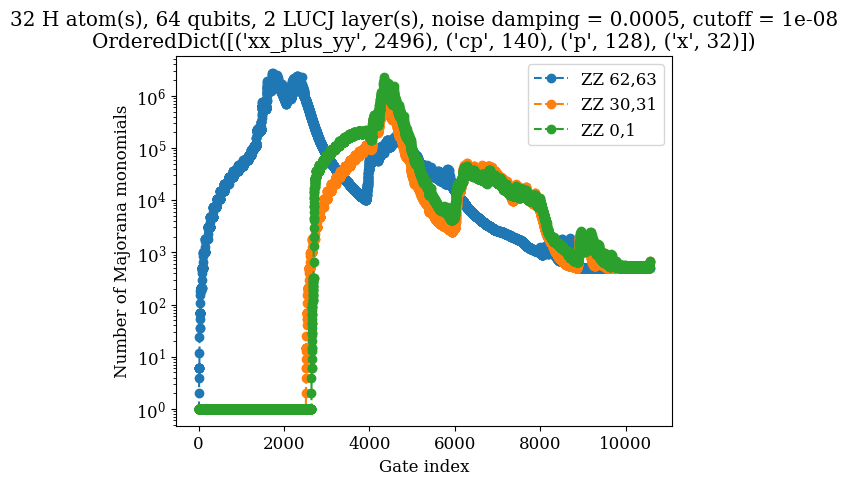

In [51]:
for i, result in enumerate(results):
    plt.semilogy(result.n_terms, "--o", label="ZZ " + ",".join(map(str, observables[i].to_sparse_list()[0][1])))

plt.xlabel("Gate index")
plt.ylabel("Number of Majorana monomials")
plt.title(f"{natoms} {atom} atom(s), {len(compiled.qubits)} qubits, {nlayers} LUCJ layer(s), noise damping = {damping}, cutoff = {cutoff}\n{compiled.count_ops()}")
plt.legend();

In [ ]:
cutoffs = [1e-4, 1e-3, 1e-3, 1e-1]
evals = []
for cutoff in cutoffs:
    print("On cutoff:", cutoff)
    prop = MajoranaPropagator(
        UniformNoiseModel(damping=0.00),
        TruncationPolicy(weight_cutoff=100000, coeff_cutoff=cutoff),
        n_threads=2,
        progress_bar=True,
    )
    mp_expectation_value = prop.expectation_value(observable_mts, mc, fock_state=0)
    evals.append(mp_expectation_value)

In [ ]:
evals = np.array(evals)

errors = np.abs(sv_expectation_value - evals)

In [ ]:
plt.semilogx(cutoffs, errors, "--o", mec="black", alpha=0.75)
plt.xlabel("Coefficient magnitude cutoff")
plt.ylabel(f"Absolute error in {observable}")
plt.title(f"{natoms} {atom} atom(s), {len(compiled.qubits)} qubits, {nlayers} LUCJ layer(s)\n{compiled.count_ops()}")